### 14. Nedan ser vi en början till modellering av ett mycket berömt dataset kopplat till blommor. Läs på vad datasetet innebär och genomför ett komplett ML-flöde. Börja med att göra ett grundläggande flöde som fungerar, därefter kan du om du önskar försöka förbättra resultatet.

In [21]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone



In [ ]:
# This code is merely executed to see the description and target names in a smooth way
iris = load_iris()
print(iris.DESCR)

In [14]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


In [15]:
X, y = load_iris(return_X_y=True, as_frame=True)
# Only choose two variables for the modelling to keep it simple
X = X[['sepal length (cm)', 'sepal width (cm)']]
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=36)

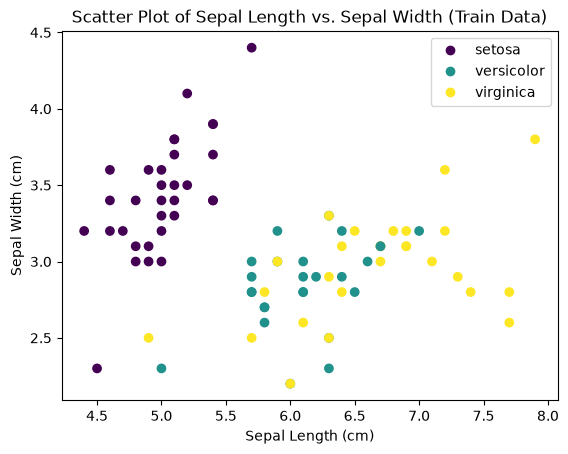

In [17]:
classes = ['setosa', 'versicolor', 'virginica'] 
scatter = plt.scatter(X_train['sepal length (cm)'], X_train['sepal width (cm)'], c=y_train) 
plt.xlabel('Sepal Length (cm)') 
plt.ylabel('Sepal Width (cm)') 
plt.title('Scatter Plot of Sepal Length vs. Sepal Width (Train Data)') 
plt.legend(handles=scatter.legend_elements()[0], labels=classes)

## Modellval med validation

Testmängden sparas helt orörd tills den slutliga utvärderingen. Modellerna tränas först på `train`, jämförs på `validation`, och den bästa modellen väljs utifrån validation accuracy.

In [ ]:
models = {
    'Logistisk regression': LogisticRegression(max_iter=1000),
    'K närmaste grannar': KNeighborsClassifier(n_neighbors=5),
    'Beslutsträd': DecisionTreeClassifier(max_depth=3, random_state=40)
}

validation_results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    validation_predictions = model.predict(X_val)
    validation_results[name] = accuracy_score(y_val, validation_predictions)

for name, score in validation_results.items():
    print(f'{name}: validation accuracy = {score:.3f}')

best_model_name = max(validation_results, key=validation_results.get)
print(f'Vald modell: {best_model_name}')

Logistisk regression: validation accuracy = 0.694
K närmaste grannar: validation accuracy = 0.611
Beslutsträd: validation accuracy = 0.667
Vald modell: Logistisk regression


## Omträning och slutlig testning

När modellen är vald tränas den om på `train + validation`. Först därefter används testmängden för den slutliga, opartiska utvärderingen.

Slutlig test accuracy: 0.933
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.92      0.92      0.92        12
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.93      0.93      0.93        30



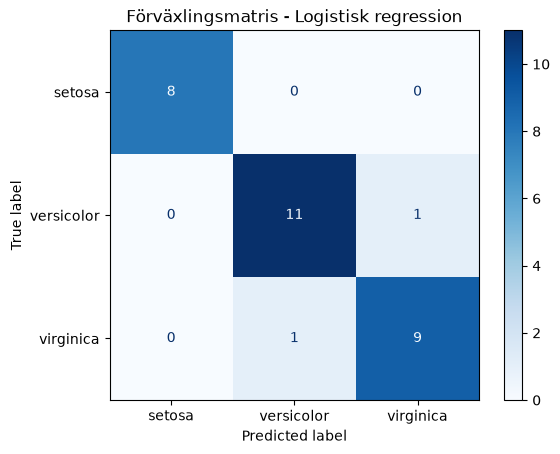

In [ ]:
# Återskapa den valda modellen med samma inställningar och träna på train + validation.
final_model = models[best_model_name].__class__(**models[best_model_name].get_params())
final_model.fit(X_train_full, y_train_full)

# Test används först nu, endast för den slutliga prediktionen.
y_test_predictions = final_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_predictions)
classes = list(iris.target_names)

print(f'Slutlig test accuracy: {test_accuracy:.3f}')
print(classification_report(y_test, y_test_predictions, target_names=classes))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_predictions,
    display_labels=classes,
    cmap='Blues'
)
plt.title(f'Förväxlingsmatris - {best_model_name}')
plt.show()

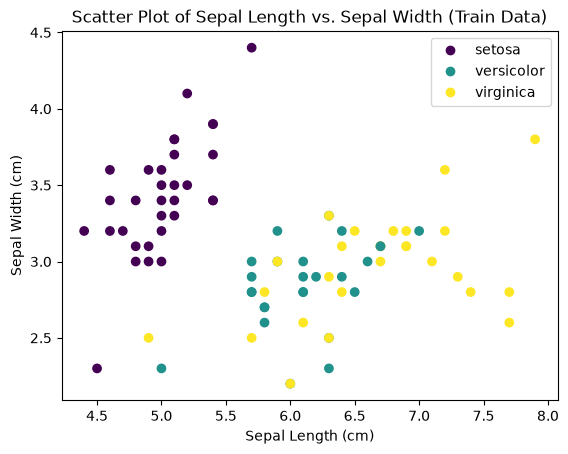

In [ ]:
classes = ['setosa', 'versicolor', 'virginica']

scatter = plt.scatter(X_train['sepal length (cm)'],
X_train['sepal width (cm)'], c=y_train)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Scatter Plot of Sepal Length vs. Sepal Width (Train Data)')
plt.legend(handles=scatter.legend_elements()[0], labels=classes)

## Förbättrat flöde med alla features

I det första flödet användes bara sepal-längd och sepal-bredd. Här används alla fyra mätvariabler. Modellerna jämförs fortfarande enbart på validation. Efter modellval tränas vinnaren om på train + validation och test används endast en gång för slutresultatet.

In [ ]:
X_all, y_all = load_iris(return_X_y=True, as_frame=True)
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=40
)
X_train_improved, X_val_improved, y_train_improved, y_val_improved = train_test_split(
    X_train_all, y_train_all, test_size=0.3, random_state=36
)

improved_models = {
    'Logistisk regression (alla features)': make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=1000)
    ),
    'SVM (alla features)': make_pipeline(
        StandardScaler(), SVC(kernel='rbf', C=1.0, gamma='scale')
    ),
    'Random Forest (alla features)': RandomForestClassifier(
        n_estimators=200, max_depth=4, random_state=40
    )
}

improved_validation_results = {}
for name, model in improved_models.items():
    model.fit(X_train_improved, y_train_improved)
    predictions = model.predict(X_val_improved)
    improved_validation_results[name] = accuracy_score(y_val_improved, predictions)

for name, score in improved_validation_results.items():
    print(f'{name}: validation accuracy = {score:.3f}')

best_improved_model_name = max(
    improved_validation_results, key=improved_validation_results.get
)
print(f'Vald förbättrad modell: {best_improved_model_name}')

Logistisk regression (alla features): validation accuracy = 0.917
SVM (alla features): validation accuracy = 0.917
Random Forest (alla features): validation accuracy = 0.861
Vald förbättrad modell: Logistisk regression (alla features)


### Slutlig utvärdering av den förbättrade modellen

Den valda förbättrade modellen tränas om på alla 120 observationer som tillhör train + validation. Testmängden består fortfarande av 30 helt orörda observationer.

Förbättrad slutlig test accuracy: 1.000
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       1.00      1.00      1.00        12
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



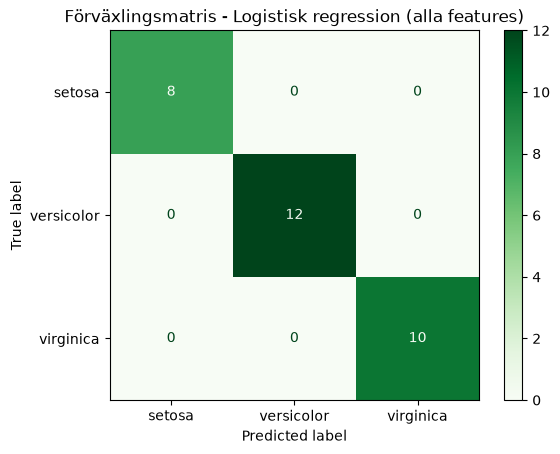

In [ ]:
final_improved_model = clone(improved_models[best_improved_model_name])
final_improved_model.fit(X_train_all, y_train_all)

# Test används först nu och endast för den slutliga utvärderingen.
y_test_improved_predictions = final_improved_model.predict(X_test_all)
improved_test_accuracy = accuracy_score(y_test_all, y_test_improved_predictions)

print(f'Förbättrad slutlig test accuracy: {improved_test_accuracy:.3f}')
print(classification_report(
    y_test_all,
    y_test_improved_predictions,
    target_names=list(iris.target_names)
))

ConfusionMatrixDisplay.from_predictions(
    y_test_all,
    y_test_improved_predictions,
    display_labels=list(iris.target_names),
    cmap='Greens'
)
plt.title(f'Förväxlingsmatris - {best_improved_model_name}')
plt.show()

### Förbättringen använder:
- Alla fyra Iris-features istället för två.
- Standardiserad logistisk regression.
- SVM och Random Forest som jämförelse.
- Validation för modellval.
- Omträning på train + validation.
- Test endast för slutlig utvärdering.
### Resultat:

* Tidigare validation accuracy: 0.694
* Förbättrad validation accuracy: 0.917
* Förbättrad test accuracy: 1.000
* Förväxlingsmatrisen visar att alla 30 testobservationer klassificerades korrekt.